In [1]:
from pathlib import Path
import warnings
import sys
import subprocess

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy import stats
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy import stats

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
DATA_PATH = Path("../../data/Maven Market Datasets/processed/maven-market-usa-weather.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/Maven Market Datasets/processed/maven-market-usa-weather.csv")

df = pd.read_csv(DATA_PATH)
display(df.head())

,transaction_date,stock_date,product_id,customer_id,store_id,quantity,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,1997-01-01,12/31/1996,869,3449,6,5,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.1200,0.9100,17.0000,1.0000,NaN,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,maven_store_6,"Beverly Hills, CA",store_city,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400,34.0736,-118.4004,34.0598,-118.3500,83.0000,America/Los_Angeles,-25200,open_meteo_archive
1,1997-01-01,12/31/1996,1472,3449,6,3,Fort West,Fort West Fudge Cookies,37276054024,2.2000,0.9000,8.2800,1.0000,NaN,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,maven_store_6,"Beverly Hills, CA",store_city,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400,34.0736,-118.4004,34.0598,-118.3500,83.0000,America/Los_Angeles,-25200,open_meteo_archive
2,1997-01-01,12/28/1996,76,3449,6,4,Red Spade,Red Spade Sliced Chicken,62054644227,1.6900,0.6900,18.1000,NaN,1.0000,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,maven_store_6,"Beverly Hills, CA",store_city,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400,34.0736,-118.4004,34.0598,-118.3500,83.0000,America/Los_Angeles,-25200,open_meteo_archive
3,1997-01-01,12/26/1996,320,3449,6,3,Excellent,Excellent Cranberry Juice,36570182442,3.2600,1.0800,16.4000,NaN,NaN,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,maven_store_6,"Beverly Hills, CA",store_city,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400,34.0736,-118.4004,34.0598,-118.3500,83.0000,America/Los_Angeles,-25200,open_meteo_archive
4,1997-01-01,12/25/1996,4,3449,6,4,Washington,Washington Cream Soda,64412155747,3.6400,1.6400,10.6000,1.0000,NaN,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,maven_store_6,"Beverly Hills, CA",store_city,51,18.4000,11.9000,14.9000,15.2000,0.1000,

In [3]:
drop_cols_safe = [
    # Thông tin định danh cá nhân / không cần cho đề tài
    "customer_acct_num",
    "first_name",
    "last_name",
    "customer_address",
    "customer_postal_code",

    # Thông tin liên hệ / địa chỉ store quá chi tiết
    "store_phone",
    "store_street_address",

    # Trùng hoặc chỉ để hiển thị
    "store_name",
    "product_sku",

    # Vì file đã lọc USA
    "store_country",

    # Metadata weather, chỉ dùng trace nguồn
    "weather_location_id",
    "location_name",
    "weather_spatial_level",
    "latitude_requested",
    "longitude_requested",
    "latitude_open_meteo",
    "longitude_open_meteo",
    "elevation_m",
    "timezone",
    "utc_offset_seconds",
    "weather_source",
]

In [4]:
drop_cols = (
    drop_cols_safe
)

drop_cols = list(dict.fromkeys(drop_cols))

In [5]:
df = df.drop(columns=drop_cols)

In [6]:
display(df.head())

,transaction_date,stock_date,product_id,customer_id,store_id,quantity,product_brand,product_name,product_retail_price,product_cost,product_weight,recyclable,low_fat,customer_city,customer_state_province,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner,region_id,store_type,store_city,store_state,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2
0,1997-01-01,12/31/1996,869,3449,6,5,Nationeel,Nationeel Grape Fruit Roll,2.1200,0.9100,17.0000,1.0000,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400
1,1997-01-01,12/31/1996,1472,3449,6,3,Fort West,Fort West Fudge Cookies,2.2000,0.9000,8.2800,1.0000,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400
2,1997-01-01,12/28/1996,76,3449,6,4,Red Spade,Red Spade Sliced Chicken,1.6900,0.6900,18.1000,NaN,1.0000,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400
3,1997-01-01,12/26/1996,320,3449,6,3,Excellent,Excellent Cranberry Juice,3.2600,1.0800,16.4000,NaN,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400
4,1997-01-01,12/25/1996,4,3449,6,4,Washington,Washington Cream Soda,3.6400,1.6400,10.6000,1.0000,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400


In [8]:
feature_dictionary_rows = [
    ("transaction_date", "time", "Ngày phát sinh giao dịch bán hàng.", "Dùng để phân tích theo thời gian hoặc join weather theo ngày."),
    ("stock_date", "time", "Ngày hàng được ghi nhận/stock trước giao dịch.", "Có thể dùng để hiểu độ trễ tồn kho so với ngày bán."),
    ("product_id", "key", "Mã định danh sản phẩm.", "Khóa join từ transaction sang product; dùng nhóm theo sản phẩm."),
    ("customer_id", "key", "Mã định danh khách hàng.", "Khóa join từ transaction sang customer; dùng phân tích hành vi khách hàng."),
    ("store_id", "key", "Mã định danh cửa hàng.", "Khóa join sang store và weather; rất quan trọng cho phân tích theo cửa hàng."),
    ("quantity", "transaction", "Số lượng sản phẩm được mua trong dòng giao dịch.", "Đây là measure gốc từ transaction, chưa phải revenue."),

    ("product_brand", "product", "Thương hiệu sản phẩm.", "Dùng phân tích doanh số theo brand."),
    ("product_name", "product", "Tên sản phẩm.", "Chi tiết hơn brand; cardinality cao nên chủ yếu dùng EDA/lookup."),
    ("product_retail_price", "product", "Giá bán lẻ của một đơn vị sản phẩm.", "Có thể kết hợp với quantity để tính gross revenue nếu cần."),
    ("product_cost", "product", "Chi phí vốn của một đơn vị sản phẩm.", "Có thể dùng để tính cost/profit nếu cần."),
    ("product_weight", "product", "Khối lượng sản phẩm.", "Feature vật lý của sản phẩm; có thể liên quan logistics hoặc category."),
    ("recyclable", "product", "Flag sản phẩm có thể tái chế.", "Biến thuộc tính sản phẩm dạng 0/1 hoặc missing từ dữ liệu gốc."),
    ("low_fat", "product", "Flag sản phẩm ít béo.", "Thuộc tính sản phẩm, đặc biệt hữu ích với nhóm food."),

    ("customer_city", "customer_geo", "Thành phố của khách hàng.", "Dùng phân tích địa lý khách hàng; không phải vị trí store."),
    ("customer_state_province", "customer_geo", "Bang/tỉnh của khách hàng.", "Có thể so sánh khách nội bang/ngoại bang với store."),
    ("customer_country", "customer_geo", "Quốc gia của khách hàng.", "Dữ liệu customer có thể đến từ USA/Canada/Mexico."),
    ("birthdate", "customer_demo", "Ngày sinh khách hàng.", "Raw date; nếu cần phân tích tuổi thì tạo age sau, nhưng hiện chưa sinh thêm feature."),
    ("marital_status", "customer_demo", "Tình trạng hôn nhân của khách hàng.", "Biến nhân khẩu học dạng categorical."),
    ("yearly_income", "customer_demo", "Nhóm thu nhập năm của khách hàng.", "Dạng income band, không phải số liên tục."),
    ("gender", "customer_demo", "Giới tính khách hàng.", "Biến nhân khẩu học categorical."),
    ("total_children", "customer_demo", "Tổng số con của khách hàng.", "Biến nhân khẩu học dạng số."),
    ("num_children_at_home", "customer_demo", "Số con đang sống tại nhà.", "Có thể ảnh hưởng basket/nhu cầu mua sắm."),
    ("education", "customer_demo", "Trình độ học vấn của khách hàng.", "Biến nhân khẩu học categorical."),
    ("acct_open_date", "customer_demo", "Ngày mở tài khoản khách hàng.", "Raw date; có thể tạo account age sau nếu cần."),
    ("member_card", "customer_demo", "Hạng thẻ thành viên.", "Có thể phản ánh loyalty level."),
    ("occupation", "customer_demo", "Nghề nghiệp khách hàng.", "Biến nhân khẩu học categorical."),
    ("homeowner", "customer_demo", "Khách hàng có sở hữu nhà hay không.", "Biến nhân khẩu học dạng Y/N."),

    ("region_id", "store", "Mã vùng bán hàng của store.", "Khóa join store sang region."),
    ("store_type", "store", "Loại cửa hàng.", "Ví dụ Supermarket, Small Grocery; ảnh hưởng scale doanh số."),
    ("store_city", "store", "Thành phố của cửa hàng.", "Vị trí store; cũng là cơ sở lấy weather."),
    ("store_state", "store", "Bang của cửa hàng.", "Trong file này là các store USA như CA/OR/WA."),
    ("first_opened_date", "store", "Ngày cửa hàng mở lần đầu.", "Raw date; có thể tạo store age sau nếu cần."),
    ("last_remodel_date", "store", "Ngày remodel gần nhất của cửa hàng.", "Raw date; có thể dùng cho phân tích vận hành."),
    ("total_sqft", "store", "Tổng diện tích cửa hàng.", "Đại diện quy mô/capacity của store."),
    ("grocery_sqft", "store", "Diện tích khu grocery trong cửa hàng.", "Có thể liên quan đến doanh số nhóm thực phẩm."),
    ("sales_district", "store_region", "Sales district của store.", "Thông tin vùng bán hàng từ bảng Regions."),
    ("sales_region", "store_region", "Sales region của store.", "Cấp vùng lớn hơn sales district."),

    ("weather_code", "weather", "Mã trạng thái thời tiết theo Open-Meteo.", "Categorical weather condition code."),
    ("temperature_max_c", "weather", "Nhiệt độ cao nhất trong ngày, độ C.", "Weather daily feature theo store location."),
    ("temperature_min_c", "weather", "Nhiệt độ thấp nhất trong ngày, độ C.", "Weather daily feature theo store location."),
    ("temperature_mean_c", "weather", "Nhiệt độ trung bình trong ngày, độ C.", "Feature thời tiết chính, thường dùng hơn max/min cho baseline."),
    ("apparent_temperature_mean_c", "weather", "Nhiệt độ cảm nhận trung bình trong ngày, độ C.", "Có thể khác temperature_mean_c do gió/độ ẩm/bức xạ."),
    ("precipitation_mm", "weather", "Tổng lượng precipitation trong ngày, mm.", "Bao gồm mưa/tuyết; dùng xem ngày có thời tiết xấu."),
    ("rain_mm", "weather", "Tổng lượng mưa trong ngày, mm.", "Gần với precipitation_mm nếu không có tuyết."),
    ("snowfall_cm", "weather", "Tổng lượng tuyết trong ngày, cm.", "Quan trọng với các bang có tuyết như WA/OR."),
    ("wind_speed_max_kmh", "weather", "Tốc độ gió lớn nhất trong ngày, km/h.", "Weather feature về gió."),
    ("wind_gusts_max_kmh", "weather", "Tốc độ gió giật lớn nhất trong ngày, km/h.", "Cực trị gió, có thể tương quan với weather severity."),
    ("shortwave_radiation_mj_m2", "weather", "Tổng bức xạ mặt trời ngắn sóng trong ngày.", "Có thể phản ánh nắng/mùa và điều kiện thời tiết."),
]

feature_dictionary = pd.DataFrame(
    feature_dictionary_rows,
    columns=["feature", "feature_group", "meaning", "note"]
)

feature_dictionary["feature"] = pd.Categorical(
    feature_dictionary["feature"],
    categories=df.columns.tolist(),
    ordered=True,
)
feature_dictionary = feature_dictionary.sort_values("feature").reset_index(drop=True)

missing_features = sorted(set(df.columns) - set(feature_dictionary["feature"].astype(str)))
extra_features = sorted(set(feature_dictionary["feature"].astype(str)) - set(df.columns))

feature_dictionary_quality = pd.DataFrame({
    "metric": ["number_of_features", "dictionary_rows", "missing_features", "extra_features"],
    "value": [df.shape[1], len(feature_dictionary), len(missing_features), len(extra_features)],
})

display(Markdown("### Data dictionary cho 48 features sau khi clean"))
display(feature_dictionary_quality)

if missing_features:
    print("Missing features:", missing_features)
if extra_features:
    print("Extra features:", extra_features)

display(feature_dictionary)


### Data dictionary cho 48 features sau khi clean

,metric,value
0,number_of_features,48
1,dictionary_rows,48
2,missing_features,0
3,extra_features,0


,feature,feature_group,meaning,note
0,transaction_date,time,Ngày phát sinh giao dịch bán hàng.,Dùng để phân tích theo thời gian hoặc join wea...
1,stock_date,time,Ngày hàng được ghi nhận/stock trước giao dịch.,Có thể dùng để hiểu độ trễ tồn kho so với ngày...
2,product_id,key,Mã định danh sản phẩm.,Khóa join từ transaction sang product; dùng nh...
3,customer_id,key,Mã định danh khách hàng.,Khóa join từ transaction sang customer; dùng p...
4,store_id,key,Mã định danh cửa hàng.,Khóa join sang store và weather; rất quan trọn...
5,quantity,transaction,Số lượng sản phẩm được mua trong dòng giao dịch.,"Đây là measure gốc từ transaction, chưa phải r..."
6,product_brand,product,Thương hiệu sản phẩm.,Dùng phân tích doanh số theo brand.
7,product_name,product,Tên sản phẩm.,Chi tiết hơn brand; cardinality cao nên chủ yế...
8,product_retail_price,product,Giá bán lẻ của một đơn vị sản phẩm.,Có thể kết hợp với quantity để tính gross reve...
9,product_cost,product,Chi phí vốn của một đơn vị sản phẩm.,Có thể dùng để tính cost/profit nếu cần.


In [11]:
weather_optional_drop = [
    "temperature_max_c",
    "temperature_min_c",
    "apparent_temperature_mean_c",
    "rain_mm",
    "wind_gusts_max_kmh",
]

df = df.drop(columns=weather_optional_drop)

In [12]:
print(df.shape)

(180823, 43)


In [13]:
unique_values = sorted(df["store_state"].dropna().unique())

print("Number of unique values:", len(unique_values))
print("\nUnique values:")

for value in unique_values:
    print(value)

Number of unique values: 3

Unique values:
CA
OR
WA


In [14]:
# Chuẩn hóa tên bang để tránh khoảng trắng
df["customer_state_clean"] = (
    df["customer_state_province"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["store_state_clean"] = (
    df["store_state"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Các bang có cửa hàng trong dữ liệu
store_states = sorted(df["store_state_clean"].dropna().unique())

print("Các bang có cửa hàng:", store_states)

Các bang có cửa hàng: ['CA', 'OR', 'WA']


In [15]:
df["customer_in_store_states"] = (
    df["customer_state_clean"].isin(store_states)
)

customer_location_summary = (
    df.groupby("customer_in_store_states")
    .agg(
        transaction_rows=("customer_id", "size"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

customer_location_summary["row_share_pct"] = (
    customer_location_summary["transaction_rows"]
    / customer_location_summary["transaction_rows"].sum()
    * 100
)

display(customer_location_summary)

,customer_in_store_states,transaction_rows,unique_customers,row_share_pct
0,True,180823,6357,100.0000


In [19]:
print(df["customer_id"].nunique())

6357


In [16]:
print(df["customer_id"].value_counts())

customer_id
4676    301
4727    297
5295    290
4021    275
5174    267
       ... 
7289      1
3894      1
1148      1
5763      1
4245      1
Name: count, Length: 6357, dtype: int64


In [20]:
customer_state_summary = (
    df.groupby("customer_state_clean", as_index=False)
    .agg(
        transaction_rows=("customer_id", "size"),
        unique_customers=("customer_id", "nunique")
    )
    .sort_values("transaction_rows", ascending=False)
)

customer_state_summary["belongs_to_store_states"] = (
    customer_state_summary["customer_state_clean"].isin(store_states)
)

display(customer_state_summary.head(30))

,customer_state_clean,transaction_rows,unique_customers,belongs_to_store_states
2,WA,86855,2034,True
0,CA,50817,3274,True
1,OR,43151,1049,True


In [21]:
df["customer_same_state_as_store"] = (
    df["customer_state_clean"] == df["store_state_clean"]
)

same_state_summary = (
    df.groupby("customer_same_state_as_store")
    .agg(
        transaction_rows=("customer_id", "size"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

same_state_summary["row_share_pct"] = (
    same_state_summary["transaction_rows"]
    / same_state_summary["transaction_rows"].sum()
    * 100
)

display(same_state_summary)

,customer_same_state_as_store,transaction_rows,unique_customers,row_share_pct
0,True,180823,6357,100.0000


In [22]:
print(df["customer_state_province"].value_counts())

customer_state_province
WA    86855
CA    50817
OR    43151
Name: count, dtype: int64


In [23]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

min_date = df["transaction_date"].min()
max_date = df["transaction_date"].max()

full_date_range = pd.date_range(
    start=min_date,
    end=max_date,
    freq="D"
)

transaction_dates = pd.DatetimeIndex(
    df["transaction_date"].dropna().dt.normalize().unique()
)

missing_dates = full_date_range.difference(transaction_dates)

print("Ngày bắt đầu:", min_date.date())
print("Ngày kết thúc:", max_date.date())
print("Tổng số ngày trong khoảng:", len(full_date_range))
print("Số ngày có giao dịch:", len(transaction_dates))
print("Số ngày không có giao dịch:", len(missing_dates))

display(
    pd.DataFrame({"missing_transaction_date": missing_dates})
)

Ngày bắt đầu: 1997-01-01
Ngày kết thúc: 1998-12-30
Tổng số ngày trong khoảng: 729
Số ngày có giao dịch: 649
Số ngày không có giao dịch: 80


,missing_transaction_date
0,1997-01-22
1,1997-01-30
2,1997-01-31
3,1997-02-06
4,1997-02-09
5,1997-02-28
6,1997-03-31
7,1997-04-11
8,1997-04-30
9,1997-05-06


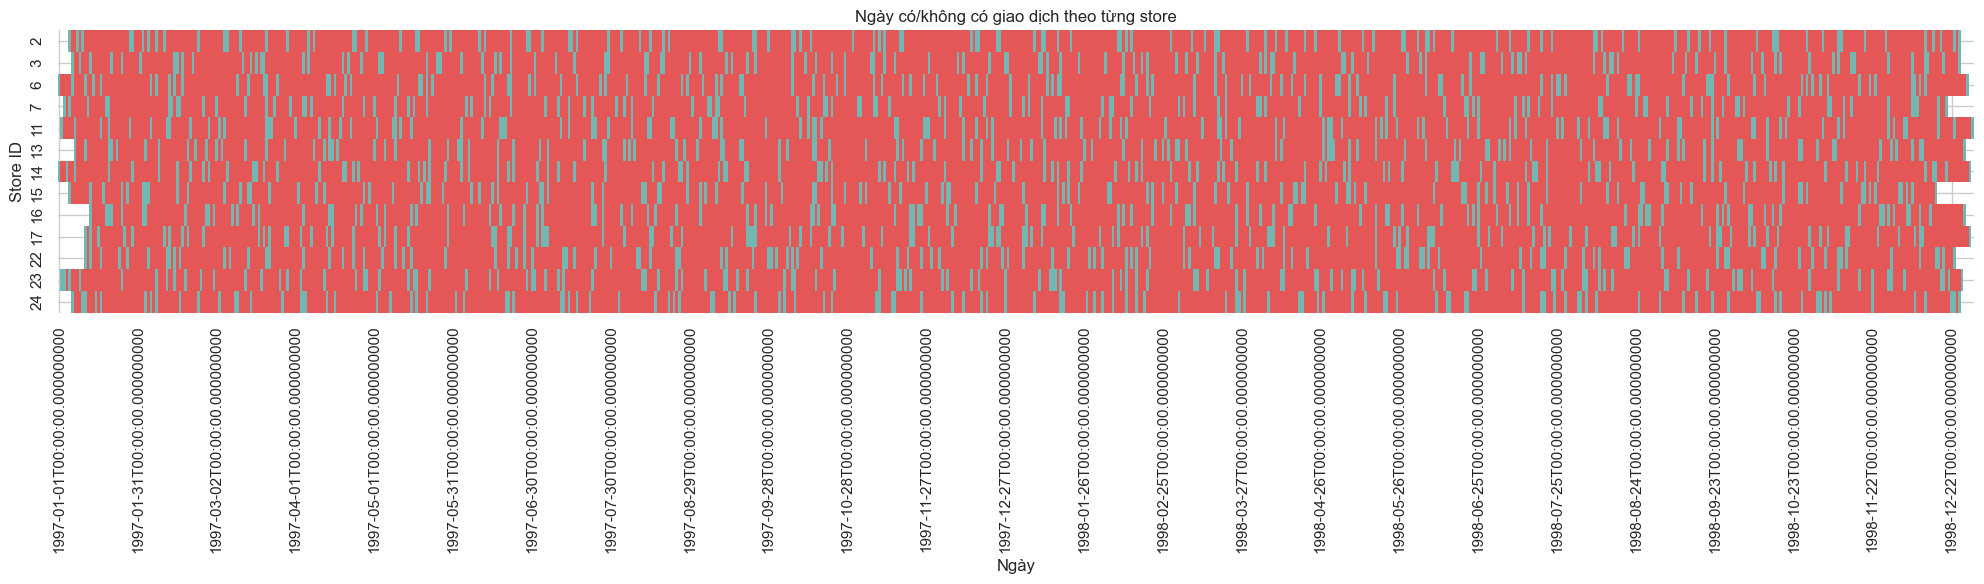

In [25]:
heatmap_data = (
    store_date_panel.pivot(
        index="store_id",
        columns="transaction_date",
        values="has_transaction"
    )
)

plt.figure(figsize=(20, 6))

sns.heatmap(
    heatmap_data,
    cmap=["#E45756", "#72B7B2"],
    cbar=False,
    xticklabels=30,
    yticklabels=True
)

plt.title("Ngày có/không có giao dịch theo từng store")
plt.xlabel("Ngày")
plt.ylabel("Store ID")
plt.tight_layout()
plt.show()

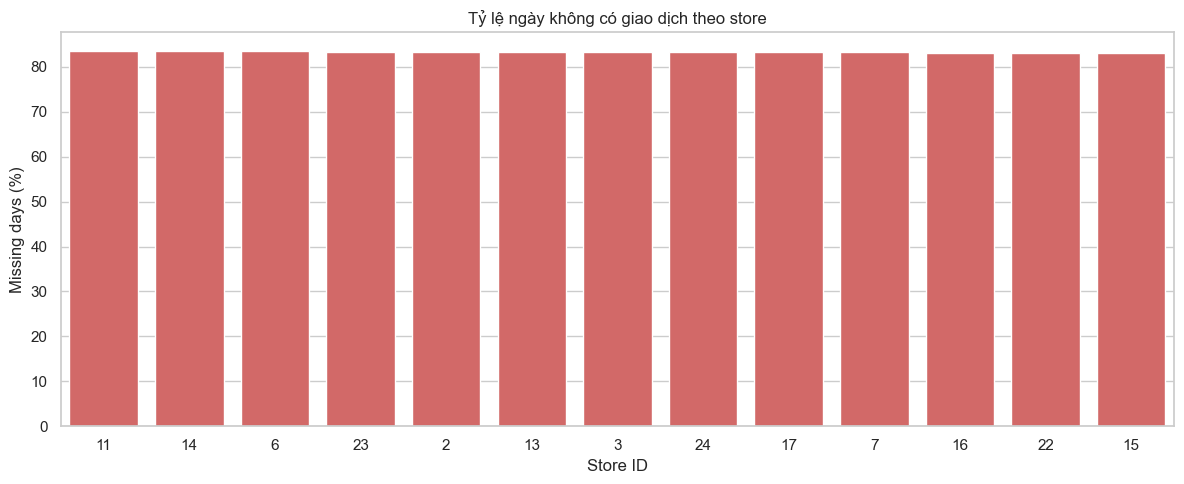

In [26]:
missing_rate_by_store = (
    store_date_panel.groupby("store_id", as_index=False)
    .agg(
        total_days=("has_transaction", "size"),
        observed_days=("has_transaction", "sum")
    )
)

missing_rate_by_store["missing_days"] = (
    missing_rate_by_store["total_days"]
    - missing_rate_by_store["observed_days"]
)

missing_rate_by_store["missing_pct"] = (
    missing_rate_by_store["missing_days"]
    / missing_rate_by_store["total_days"]
    * 100
)

missing_rate_by_store = missing_rate_by_store.sort_values(
    "missing_pct",
    ascending=False
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=missing_rate_by_store,
    x="store_id",
    y="missing_pct",
    color="#E45756",
    order=missing_rate_by_store["store_id"]
)

plt.title("Tỷ lệ ngày không có giao dịch theo store")
plt.xlabel("Store ID")
plt.ylabel("Missing days (%)")
plt.tight_layout()
plt.show()

In [27]:
print(df["store_id"].nunique())

13


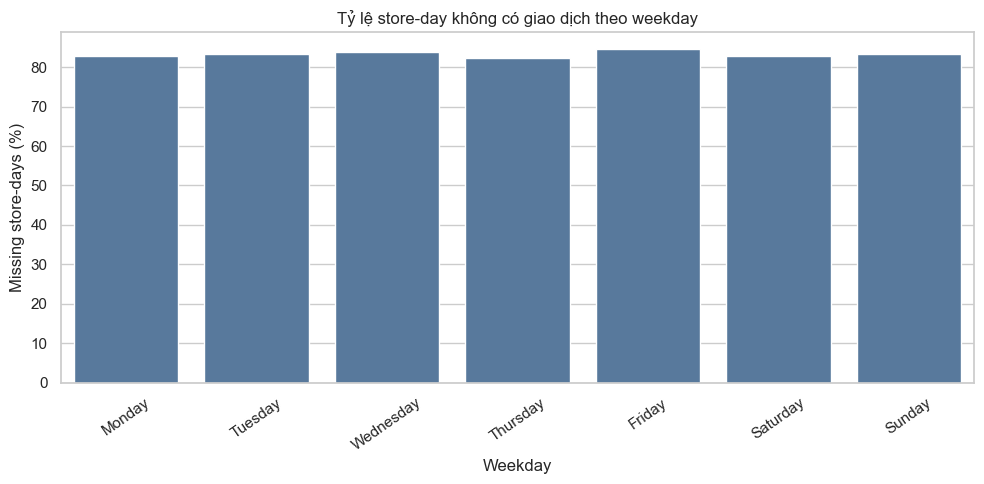

In [28]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_panel = store_date_panel.copy()

weekday_panel["day_of_week"] = (
    weekday_panel["transaction_date"].dt.day_name()
)

weekday_missing = (
    weekday_panel.groupby("day_of_week", as_index=False)
    .agg(
        total_store_days=("has_transaction", "size"),
        observed_store_days=("has_transaction", "sum")
    )
)

weekday_missing["missing_days"] = (
    weekday_missing["total_store_days"]
    - weekday_missing["observed_store_days"]
)

weekday_missing["missing_pct"] = (
    weekday_missing["missing_days"]
    / weekday_missing["total_store_days"]
    * 100
)

weekday_missing["day_of_week"] = pd.Categorical(
    weekday_missing["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_missing = weekday_missing.sort_values("day_of_week")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_missing,
    x="day_of_week",
    y="missing_pct",
    color="#4C78A8"
)

plt.title("Tỷ lệ store-day không có giao dịch theo weekday")
plt.xlabel("Weekday")
plt.ylabel("Missing store-days (%)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

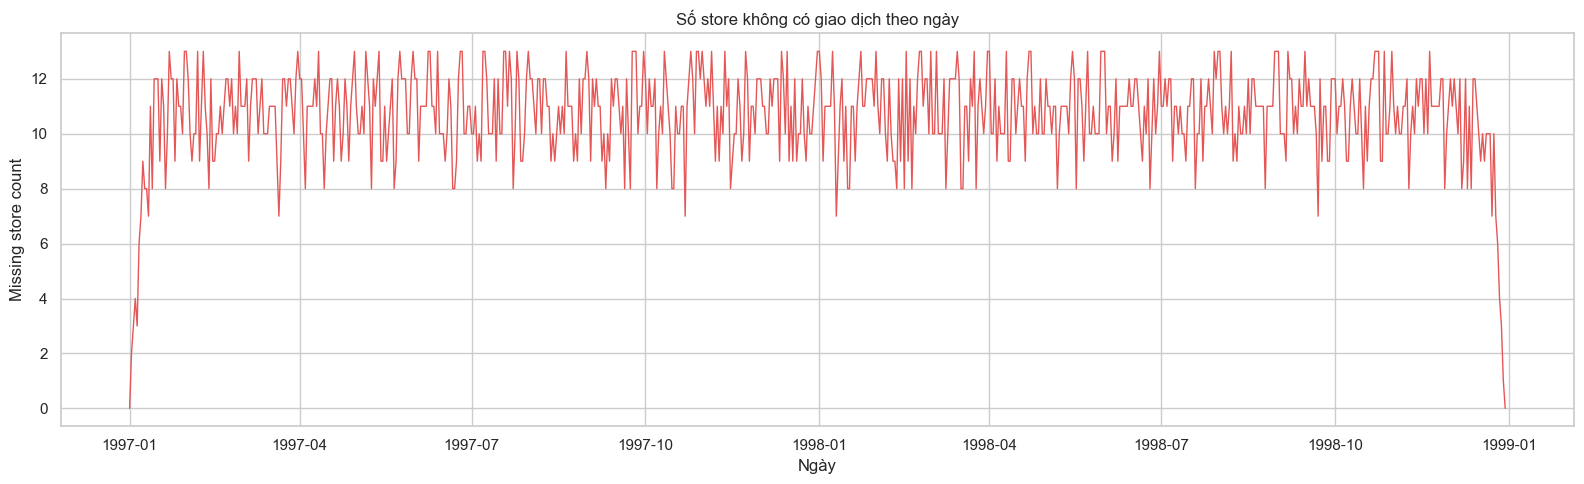

In [29]:
missing_by_date_plot = (
    store_date_panel.groupby("transaction_date", as_index=False)
    .agg(
        total_stores=("store_id", "nunique"),
        observed_stores=("has_transaction", "sum")
    )
)

missing_by_date_plot["missing_store_count"] = (
    missing_by_date_plot["total_stores"]
    - missing_by_date_plot["observed_stores"]
)

plt.figure(figsize=(16, 5))

plt.plot(
    missing_by_date_plot["transaction_date"],
    missing_by_date_plot["missing_store_count"],
    color="#E45756",
    linewidth=1
)

plt.title("Số store không có giao dịch theo ngày")
plt.xlabel("Ngày")
plt.ylabel("Missing store count")
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_check = df.copy()
df_check["transaction_date"] = pd.to_datetime(
    df_check["transaction_date"],
    errors="coerce"
)

# Tất cả ngày và store trong dữ liệu
all_dates = pd.date_range(
    df_check["transaction_date"].min(),
    df_check["transaction_date"].max(),
    freq="D"
)

all_stores = sorted(df_check["store_id"].dropna().unique())

# Tạo đầy đủ tổ hợp ngày x store
full_panel = pd.MultiIndex.from_product(
    [all_dates, all_stores],
    names=["transaction_date", "store_id"]
).to_frame(index=False)

# Những ngày-store thực sự có giao dịch
observed = (
    df_check[["transaction_date", "store_id"]]
    .drop_duplicates()
    .assign(has_transaction=1)
)

full_panel = full_panel.merge(
    observed,
    on=["transaction_date", "store_id"],
    how="left"
)

full_panel["has_transaction"] = (
    full_panel["has_transaction"]
    .fillna(0)
    .astype(int)
)

# Tổng hợp theo từng ngày
daily_status = (
    full_panel.groupby("transaction_date")
    .agg(
        active_store_count=("has_transaction", "sum"),
        total_store_count=("store_id", "nunique")
    )
    .reset_index()
)

daily_status["missing_store_count"] = (
    daily_status["total_store_count"]
    - daily_status["active_store_count"]
)

daily_status["all_stores_missing"] = (
    daily_status["active_store_count"] == 0
)

daily_status["all_stores_active"] = (
    daily_status["active_store_count"]
    == daily_status["total_store_count"]
)

print("Tổng số ngày:", len(daily_status))
print("Tổng số store:", len(all_stores))
print(
    "Ngày tất cả store đều không có giao dịch:",
    daily_status["all_stores_missing"].sum()
)
print(
    "Ngày tất cả store đều có giao dịch:",
    daily_status["all_stores_active"].sum()
)
print(
    "Số store xuất hiện nhiều nhất trong một ngày:",
    daily_status["active_store_count"].max()
)

display(
    daily_status[daily_status["all_stores_missing"]]
    [["transaction_date"]]
)

Tổng số ngày: 729
Tổng số store: 13
Ngày tất cả store đều không có giao dịch: 80
Ngày tất cả store đều có giao dịch: 0
Số store xuất hiện nhiều nhất trong một ngày: 6


,transaction_date
21,1997-01-22
29,1997-01-30
30,1997-01-31
36,1997-02-06
39,1997-02-09
58,1997-02-28
89,1997-03-31
100,1997-04-11
119,1997-04-30
125,1997-05-06


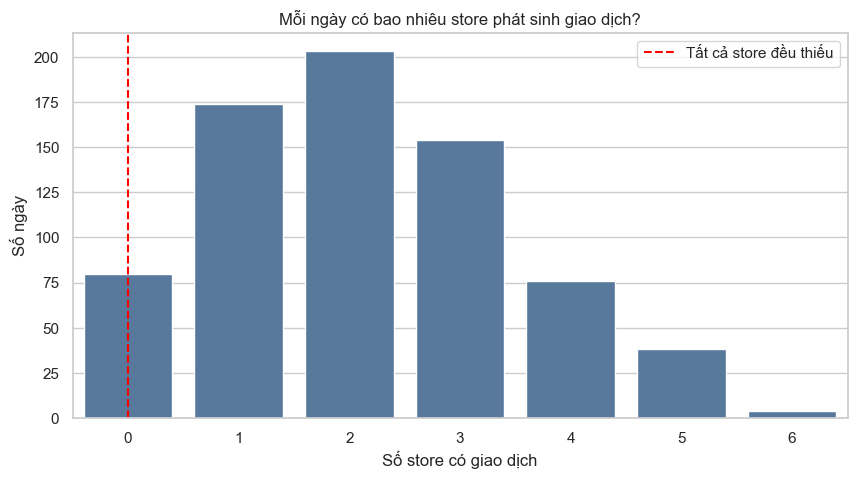

In [31]:
active_distribution = (
    daily_status["active_store_count"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=active_distribution.index,
    y=active_distribution.values,
    color="#4C78A8"
)

plt.title("Mỗi ngày có bao nhiêu store phát sinh giao dịch?")
plt.xlabel("Số store có giao dịch")
plt.ylabel("Số ngày")
plt.axvline(0, color="red", linestyle="--", label="Tất cả store đều thiếu")
plt.legend()
plt.show()

In [4]:
DATA_PATH = Path("maven-market-usa-processed.csv")

df = pd.read_csv(DATA_PATH)
display(df.head())

,transaction_date,stock_date,product_id,customer_id,store_id,quantity,product_brand,product_name,product_retail_price,product_cost,product_weight,recyclable,low_fat,customer_city,customer_state_province,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner,region_id,store_type,store_city,store_state,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,weather_code,temperature_mean_c,precipitation_mm,snowfall_cm,wind_speed_max_kmh,shortwave_radiation_mj_m2,customer_state_clean,store_state_clean,customer_in_store_states,customer_same_state_as_store
0,1997-01-01,12/31/1996,869,3449,6,5,Nationeel,Nationeel Grape Fruit Roll,2.1200,0.9100,17.0000,1.0000,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,CA,CA,True,True
1,1997-01-01,12/31/1996,1472,3449,6,3,Fort West,Fort West Fudge Cookies,2.2000,0.9000,8.2800,1.0000,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,CA,CA,True,True
2,1997-01-01,12/28/1996,76,3449,6,4,Red Spade,Red Spade Sliced Chicken,1.6900,0.6900,18.1000,NaN,1.0000,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,CA,CA,True,True
3,1997-01-01,12/26/1996,320,3449,6,3,Excellent,Excellent Cranberry Juice,3.2600,1.0800,16.4000,NaN,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,CA,CA,True,True
4,1997-01-01,12/25/1996,4,3449,6,4,Washington,Washington Cream Soda,3.6400,1.6400,10.6000,1.0000,NaN,Pomona,CA,USA,11/26/1979,M,$30K - $50K,F,2,0,High School Degree,12/7/1994,Bronze,Skilled Manual,Y,47,Gourmet Supermarket,Beverly Hills,CA,1/3/1981,3/13/1991,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,CA,CA,True,True


In [5]:
drop_cols = [
    "customer_state_clean",
    "store_state_clean",
    "customer_in_store_states",
    "customer_same_state_as_store"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [6]:
df.to_csv("output.csv", index=False)

In [7]:
df.shape

(180823, 43)